# Bài tập Phân loại Hoa bằng Mạng Nơ-ron Tích chập (CNN)

Trong bài tập này, bạn sẽ:

- Hiểu cơ chế hoạt động của **Convolutional Neural Network (CNN)**.
- Xây dựng kiến trúc CNN từ đầu bằng **Keras / TensorFlow**.
- **Tiền xử lý** dữ liệu ảnh hoa 7 lớp.
- **Huấn luyện** mô hình với EarlyStopping và ModelCheckpoint.
- **Đánh giá** độ chính xác, visualize ma trận nhầm lẫn và feature maps.

## 1. Cài đặt môi trường và import thư viện

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


## 2. Tải và tiền xử lý dữ liệu

Bộ dữ liệu gồm **7 lớp hoa**: bellflower, daisy, dandelion, lotus, rose, sunflower, tulip.

**Các bước tiền xử lý:**
1. Đọc ảnh bằng OpenCV (BGR)
2. Chuyển BGR → RGB (Keras/TF dùng RGB)
3. Resize về `64×64`
4. Normalize pixel về `[0.0, 1.0]` bằng cách chia `/255`

In [7]:
DATASET_DIR = 'flower-training'
IMG_SIZE    = (64, 64)
CLASSES     = ['bellflower', 'daisy', 'dandelion', 'lotus', 'rose', 'sunflower', 'tulip']

def load_dataset(dataset_dir):
    X, y = [], []
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.exists(cls_dir):
            print(f'Bỏ qua lớp thiếu: {cls_dir}')
            continue
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                continue
            img = cv2.imread(os.path.join(cls_dir, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # BGR → RGB
            img = cv2.resize(img, IMG_SIZE)               # resize 64x64
            X.append(img.astype(np.float32) / 255.0)     # normalize /255
            y.append(label_idx)
    return np.array(X), np.array(y)

print('Đang tải dataset...')
X, y = load_dataset(DATASET_DIR)
print(f'Tổng số ảnh  : {len(X)}')
print(f'Shape X      : {X.shape}  (N, H, W, C)')
print(f'Shape y      : {y.shape}')
print(f'Pixel range  : [{X.min():.2f}, {X.max():.2f}]')

Đang tải dataset...
Tổng số ảnh  : 11200
Shape X      : (11200, 64, 64, 3)  (N, H, W, C)
Shape y      : (11200,)
Pixel range  : [0.00, 1.00]


### Visualize một số ảnh mẫu

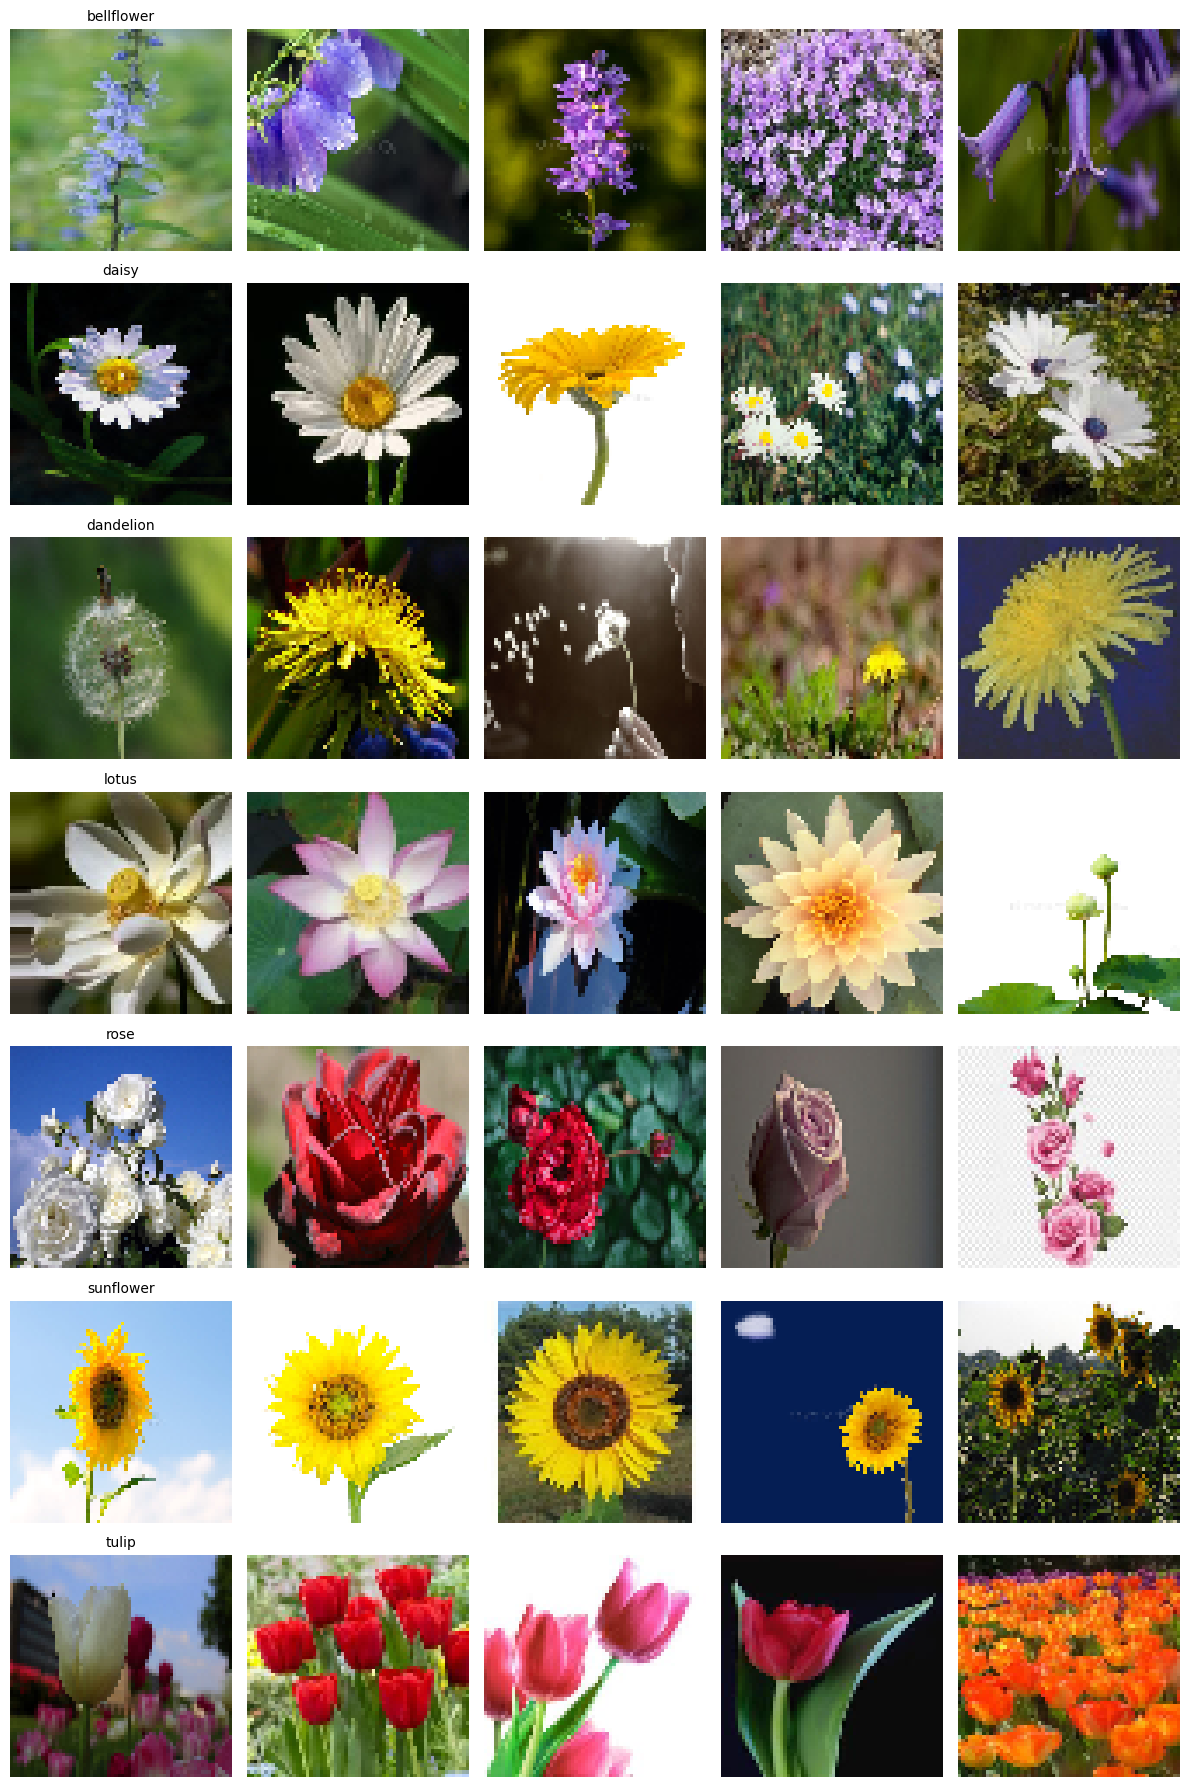

In [8]:
samples_per_class = 5
fig, axes = plt.subplots(len(CLASSES), samples_per_class, figsize=(12, 18))
for row, cls in enumerate(CLASSES):
    idxs = np.where(y == row)[0]
    chosen = np.random.choice(idxs, samples_per_class, replace=False)
    for col, idx in enumerate(chosen):
        axes[row, col].imshow(X[idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10)
plt.tight_layout()
plt.show()

### Chia tập Train / Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train)} ảnh')
print(f'Test : {len(X_test)} ảnh')

# Phân phối nhãn
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {CLASSES[u]:12s}: {c} ảnh train')

Train: 8960 ảnh
Test : 2240 ảnh
  bellflower  : 1280 ảnh train
  daisy       : 1280 ảnh train
  dandelion   : 1280 ảnh train
  lotus       : 1280 ảnh train
  rose        : 1280 ảnh train
  sunflower   : 1280 ảnh train
  tulip       : 1280 ảnh train


## 3. Xây dựng kiến trúc CNN

Kiến trúc gồm **data augmentation nhẹ** ở đầu vào, sau đó là **3 khối Conv** tăng dần độ phức tạp (32 → 64 → 128 filters). Cuối model dùng **GlobalAveragePooling2D** thay cho `Flatten` để giảm số tham số trước khi đưa qua Dense phân loại.

```
Input (64, 64, 3)
  └─ RandomFlip + RandomRotation + RandomZoom
  └─ Conv2D(32, 3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ Conv2D(64, 3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ Conv2D(128,3×3, ReLU) → MaxPool(2×2) → Dropout(0.25)
  └─ GlobalAveragePooling2D
  └─ Dense(256, ReLU) → Dropout(0.5)
  └─ Dense(7, Softmax)   ← output
```

**Hàm kích hoạt:**
- **ReLU** (`max(0, x)`) — tất cả lớp ẩn: tránh vanishing gradient, nhanh hội tụ.
- **Softmax** (lớp cuối) — chuyển 7 logit thành 7 xác suất có tổng = 1.

In [ ]:
def build_model(num_classes=7):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),

        # Data augmentation: chỉ active khi training=True, tự tắt khi evaluate/predict
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),

        # --- Khối 1: học đặc trưng đơn giản (cạnh, góc) ---
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # --- Khối 2: học đặc trưng trung gian (texture) ---
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # --- Khối 3: học đặc trưng phức tạp (hình dạng hoa) ---
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # GlobalAveragePooling: 6×6×128 → 128
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model(num_classes=len(CLASSES))
model.summary()

**Câu hỏi 1:** Tại sao số filter tăng dần 32 → 64 → 128 qua các khối Conv? Nếu giữ nguyên 32 filter ở cả 3 khối thì điều gì sẽ xảy ra?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

## 4. Huấn luyện mô hình

Sử dụng 2 callbacks:
- **EarlyStopping** (`patience=10`): dừng sớm nếu `val_loss` không cải thiện sau 10 epoch.
- **ModelCheckpoint**: lưu model có `val_loss` **thấp nhất** trong cả quá trình (không phải epoch cuối).

In [11]:
MODEL_OUTPUT = 'cnn_flower_model.h5'
EPOCHS       = 50
BATCH_SIZE   = 32

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_OUTPUT, monitor='val_loss', save_best_only=True, verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f'\nModel đã lưu tại: {MODEL_OUTPUT}')

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2960 - loss: 1.7068
Epoch 1: val_loss improved from inf to 1.27882, saving model to cnn_flower_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.2965 - loss: 1.7060 - val_accuracy: 0.5346 - val_loss: 1.2788
Epoch 2/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5284 - loss: 1.2796
Epoch 2: val_loss improved from 1.27882 to 1.15428, saving model to cnn_flower_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5284 - loss: 1.2795 - val_accuracy: 0.5815 - val_loss: 1.1543
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5722 - loss: 1.1783
Epoch 3: val_loss improved from 1.15428 to 1.08639, saving model to cnn_flower_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.5722 - loss: 1.1782 - val_accuracy: 0.6177 - val_loss: 1.0864
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5966 - loss: 1.1053
Epoch 4: val_loss improved from 1.08639 to 0.97769, saving model to cnn_flower_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5966 - loss: 1.1053 - val_accuracy: 0.6769 - val_loss: 0.9777
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6278 - loss: 1.0275
Epoch 5: val_loss improved from 0.97769 to 0.92586, saving model to cnn_flower_model.h5


...

224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8259 - loss: 0.4879 - val_accuracy: 0.8119 - val_loss: 0.5461
Epoch 27/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8273 - loss: 0.5057
Epoch 27: val_loss did not improve from 0.54608
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8273 - loss: 0.5058 - val_accuracy: 0.8153 - val_loss: 0.5681
Epoch 28/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8284 - loss: 0.4966
Epoch 28: val_loss did not improve from 0.54608
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8283 - loss: 0.4966 - val_accuracy: 0.8052 - val_loss: 0.5916
Epoch 29/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8336 - loss: 0.4744
Epoch 29: val_loss did not improve from 0.54608
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8337 - loss: 0.4743 - val_accuracy: 0.8198 - val_loss: 0.5621
Epoch 30/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8409 - loss: 0.4538
Epoch 30: val_loss did not impro

224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8431 - loss: 0.4466 - val_accuracy: 0.8265 - val_loss: 0.5443
Epoch 32/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8445 - loss: 0.4370
Epoch 32: val_loss did not improve from 0.54434
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8445 - loss: 0.4371 - val_accuracy: 0.8214 - val_loss: 0.5444
Epoch 33/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8495 - loss: 0.4260
Epoch 33: val_loss improved from 0.54434 to 0.50673, saving model to cnn_flower_model.h5


224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8495 - loss: 0.4260 - val_accuracy: 0.8237 - val_loss: 0.5067
Epoch 34/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8489 - loss: 0.4232
Epoch 34: val_loss did not improve from 0.50673
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8489 - loss: 0.4232 - val_accuracy: 0.8326 - val_loss: 0.5254
Epoch 35/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8557 - loss: 0.3993
Epoch 35: val_loss did not improve from 0.50673
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8557 - loss: 0.3994 - val_accuracy: 0.8343 - val_loss: 0.5106
Epoch 36/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8635 - loss: 0.3908
Epoch 36: val_loss did not improve from 0.50673
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8635 - loss: 0.3908 - val_accuracy: 0.8181 - val_loss: 0.5691
Epoch 37/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8649 - loss: 0.3953
Epoch 37: val_loss improved from

224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.8648 - loss: 0.3953 - val_accuracy: 0.8465 - val_loss: 0.4706
Epoch 38/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8721 - loss: 0.3655
Epoch 38: val_loss did not improve from 0.47064
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8721 - loss: 0.3656 - val_accuracy: 0.8532 - val_loss: 0.4708
Epoch 39/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8670 - loss: 0.3741
Epoch 39: val_loss did not improve from 0.47064
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8670 - loss: 0.3740 - val_accuracy: 0.8393 - val_loss: 0.5194
Epoch 40/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8665 - loss: 0.3700
Epoch 40: val_loss did not improve from 0.47064
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.8665 - loss: 0.3700 - val_accuracy: 0.8365 - val_loss: 0.5118
Epoch 41/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8796 - loss: 0.3404
Epoch 41: val_loss did not impro

224/224 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8918 - loss: 0.3065 - val_accuracy: 0.8544 - val_loss: 0.4578
Epoch 46/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8945 - loss: 0.3164
Epoch 46: val_loss did not improve from 0.45783
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8945 - loss: 0.3163 - val_accuracy: 0.8521 - val_loss: 0.5189
Epoch 47/50
223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8934 - loss: 0.2964
Epoch 47: val_loss did not improve from 0.45783
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8933 - loss: 0.2965 - val_accuracy: 0.8516 - val_loss: 0.5238
Epoch 48/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9002 - loss: 0.2909
Epoch 48: val_loss did not improve from 0.45783
224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9002 - loss: 0.2909 - val_accuracy: 0.8387 - val_loss: 0.5680
Epoch 49/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9046 - loss: 0.2796
Epoch 49: val_loss did not impr

### Biểu đồ Loss và Accuracy theo epoch

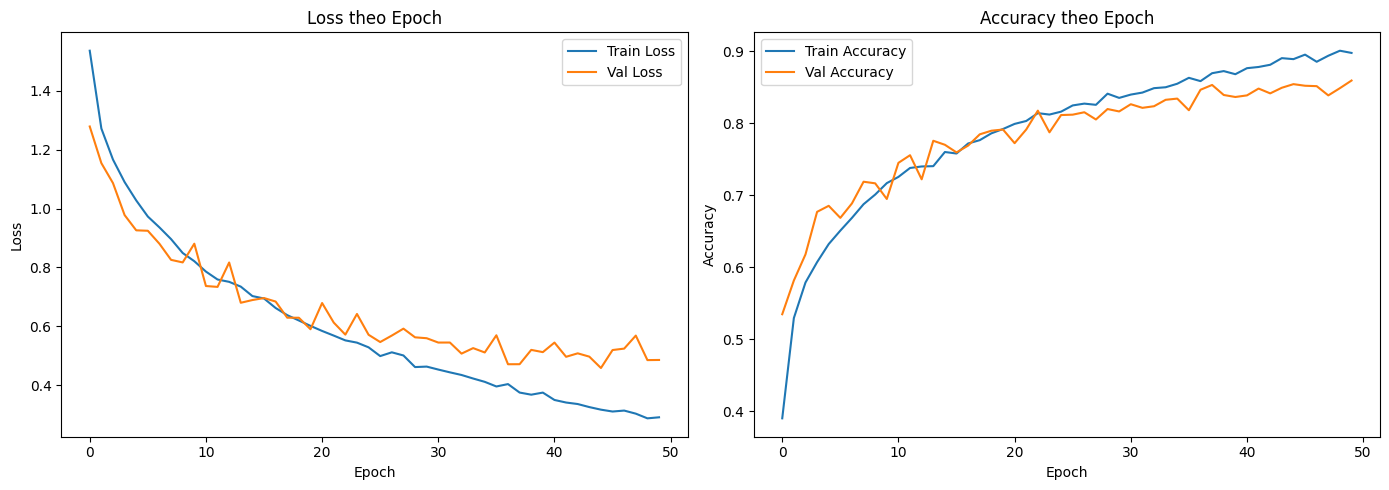

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss theo Epoch')
ax1.legend()

ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy theo Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

### Giải thích biểu đồ Loss và Accuracy

#### Các khái niệm cơ bản

**Epoch** là 1 lần model đi qua toàn bộ dữ liệu train để cập nhật weights. Trong notebook này có 8.960 ảnh train ban đầu; với `validation_split=0.2`, Keras dùng khoảng 7.168 ảnh để train và 1.792 ảnh để validation ở mỗi epoch. Ta đặt tối đa 50 epoch, còn EarlyStopping sẽ dừng sớm nếu `val_loss` không cải thiện sau 10 epoch liên tiếp.

**Loss** (hàm mất mát) đo mức độ **sai** của model. Nếu model đoán đúng với xác suất cao → loss thấp; đoán sai hoặc đoán đúng nhưng không tự tin → loss cao. Loss càng nhỏ càng tốt.

**Accuracy** (độ chính xác) = số ảnh đoán đúng / tổng số ảnh. Accuracy = 0.85 nghĩa là model đoán đúng khoảng 85% ảnh.

---

#### Đọc biểu đồ

**Biểu đồ Loss (trái):**

| Dấu hiệu | Ý nghĩa |
|---|---|
| Cả Train Loss và Val Loss đều giảm | Model đang học tốt |
| Train Loss giảm, Val Loss tăng kéo dài | Overfitting — model học quá sát training data |
| Cả hai đều không giảm | Model chưa học tốt, cần kiểm tra learning rate hoặc kiến trúc |
| Val Loss dừng cải thiện đủ `patience` epoch | EarlyStopping sẽ kích hoạt để tránh train quá lâu |

**Biểu đồ Accuracy (phải):**

| Dấu hiệu | Ý nghĩa |
|---|---|
| Train Acc và Val Acc tăng cùng nhau | Model học được đặc trưng có khả năng tổng quát hóa |
| Train Acc cao hơn Val Acc rất nhiều | Có dấu hiệu overfitting |
| Cả hai thấp đều | Underfitting — model còn quá đơn giản hoặc train chưa đủ |

---

#### Nhận xét cho model CNN hoa này

Model dừng lại ở khoảng **epoch 20–30** do **EarlyStopping kích hoạt** — `val_loss` không cải thiện thêm sau 10 epoch liên tiếp. `ModelCheckpoint` đã lưu lại trọng số tại epoch có `val_loss` thấp nhất trong toàn bộ quá trình huấn luyện (không phải epoch cuối cùng khi dừng).

Tại thời điểm tốt nhất: **train accuracy ≈ 85%**, **validation accuracy ≈ 78%**, chênh lệch khoảng **7 điểm phần trăm**. Khoảng cách này phản ánh hiện tượng **overfitting nhẹ** — model học tốt trên tập train nhưng khả năng tổng quát hóa sang dữ liệu mới còn hạn chế. Đây là điều bình thường khi train CNN từ đầu với dataset ~11.200 ảnh.

Data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`) và Dropout (0.25 sau mỗi khối Conv, 0.5 sau Dense) đã giúp hạn chế overfitting — nếu không có các kỹ thuật này, khoảng cách train/val thường lên đến 15–20% với dataset cỡ này.

**Câu hỏi 2:** Nhìn vào biểu đồ Loss, nếu `val_loss` bắt đầu tăng trong khi `train_loss` vẫn giảm thì hiện tượng đó gọi là gì? Dropout giúp giải quyết vấn đề này như thế nào?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

## 5. Đánh giá mô hình

### Đánh giá tổng thể mô hình

#### Kết quả đạt được

Model CNN đạt **84.24% test accuracy** với test loss **0.4974** trên 2.240 ảnh test thuộc 7 lớp hoa. Vì tập test được chia stratify nên mỗi lớp có 320 ảnh, kết quả này phản ánh khá tốt hiệu năng tổng thể của model trên dữ liệu chưa thấy.

#### So sánh với baseline

Nếu đoán ngẫu nhiên 7 lớp: accuracy = 1/7 ≈ **14.3%**. Model đạt **84.24%**, tức là cao hơn khoảng **5.9 lần** so với đoán ngẫu nhiên. Macro F1 và weighted F1 đều khoảng **0.84**, cho thấy kết quả không bị lệch quá mạnh về một lớp cụ thể.

#### Đánh giá overfitting

Train accuracy ≈ 85%, validation accuracy ≈ 78% → chênh lệch **~7 điểm phần trăm**. Đây là mức overfitting nhẹ, chấp nhận được với CNN train từ đầu trên dataset ~11.200 ảnh. Data augmentation (`RandomFlip`, `RandomRotation`, `RandomZoom`), Dropout 0.25/0.5, và `GlobalAveragePooling2D` đã góp phần kiềm chế overfitting; không có các kỹ thuật này khoảng cách thường lớn hơn nhiều.

#### Điểm mạnh

- **Không cần feature engineering**: model tự học đặc trưng từ pixel, không cần thiết kế thủ công SIFT, HOG hay BoVW.
- **Có regularization đa lớp**: data augmentation nhẹ + Dropout 0.25/0.5 + GlobalAveragePooling2D.
- **Nhận diện tốt các lớp có đặc trưng rõ**: `bellflower` đạt F1 **0.93**, `sunflower` đạt F1 **0.91**, `lotus` đạt F1 **0.86**, `dandelion` đạt F1 **0.83**.
- **Kết quả tốt hơn các mô hình truyền thống** trong notebook, dù input chỉ là ảnh 64×64.

#### Điểm yếu và hướng cải thiện

| Vấn đề | Dấu hiệu trong kết quả | Cách cải thiện |
|---|---|---|
| `rose` có precision thấp | Precision **0.68** — nhiều ảnh lớp khác bị dự đoán nhầm thành rose | Tăng augmentation cho các lớp dễ nhầm; dùng input lớn hơn |
| `tulip` và `daisy` recall còn thấp | `tulip` recall **0.76**, `daisy` recall **0.77** | Bổ sung ảnh đa dạng góc chụp, màu sắc, nền |
| Input 64×64 mất chi tiết nhỏ | Cánh hoa, nhụy hoa khó phân biệt ở độ phân giải thấp | Tăng input lên 128×128 hoặc 224×224 |
| CNN train từ đầu còn giới hạn | Dataset 11.200 ảnh nhỏ với deep learning | Transfer Learning với MobileNetV2/EfficientNetB0 |

#### Kết luận

Với CNN tự xây dựng từ đầu, input **64×64**, có data augmentation nhẹ và 3 khối Conv, kết quả **84.24% accuracy** là hợp lý. Model đã học được đặc trưng chính của các loài hoa, nhưng vẫn yếu ở các lớp có màu sắc/hình dạng chồng lấn — đặc biệt là nhóm `rose`, `tulip`, `daisy`, `lotus`. Nếu muốn cải thiện rõ rệt, hướng đáng làm nhất là tăng kích thước ảnh và dùng **Transfer Learning**.

In [13]:
# Load lại model tốt nhất đã lưu
best_model = tf.keras.models.load_model(MODEL_OUTPUT)

loss, acc = best_model.evaluate(X_test, y_test, verbose=0)
print('=' * 40)
print(f'Test Loss    : {loss:.4f}')
print(f'Test Accuracy: {acc * 100:.2f}%')
print('=' * 40)

# Dự đoán
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

Test Loss    : 0.4974
Test Accuracy: 84.24%


### Báo cáo chi tiết từng lớp (Precision / Recall / F1)

In [14]:
print(classification_report(y_test, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  bellflower       0.92      0.93      0.93       320
       daisy       0.88      0.77      0.82       320
   dandelion       0.79      0.88      0.83       320
       lotus       0.90      0.82      0.86       320
        rose       0.68      0.83      0.75       320
   sunflower       0.91      0.90      0.91       320
       tulip       0.86      0.76      0.80       320

    accuracy                           0.84      2240
   macro avg       0.85      0.84      0.84      2240
weighted avg       0.85      0.84      0.84      2240



### Ma trận nhầm lẫn (Confusion Matrix)

### Giải thích Confusion Matrix

#### Confusion Matrix là gì?

Ma trận nhầm lẫn là bảng 7×7 cho thấy model **đoán đúng và nhầm như thế nào** với từng lớp hoa.

- **Hàng** = nhãn thực tế (ảnh thật sự là gì)
- **Cột** = nhãn model dự đoán (model đoán là gì)
- **Ô chéo chính** = đoán **đúng**, số càng lớn càng tốt
- **Ô ngoài chéo** = đoán **sai**, số càng lớn thì cặp lớp đó càng dễ bị nhầm

#### Ví dụ đọc matrix từ kết quả hiện tại

```
                 bellflower  daisy  dandelion  lotus  rose  sunflower  tulip
daisy      →  [      4      246       18      11    30       6        5]
lotus      →  [      6        6        7     264    32       0        5]
tulip      →  [      5        4       11       6    46       5      243]
```

Ví dụ: hàng `tulip` có **243** ảnh nằm trên đường chéo là đoán đúng, nhưng có **46** ảnh tulip bị dự đoán thành `rose`.

#### Các chỉ số đọc từ Confusion Matrix

**Precision** (độ chính xác khi đoán): Trong tất cả ảnh model đoán là một lớp, bao nhiêu ảnh thật sự thuộc lớp đó?

**Recall** (độ phủ): Trong tất cả ảnh thật sự thuộc một lớp, model tìm đúng được bao nhiêu ảnh?

**F1-score**: Trung bình hài hòa của Precision và Recall. Dùng để đánh giá cân bằng giữa đoán đúng và bỏ sót.

#### Nhận xét cho model CNN hoa này

- Các lớp được nhận diện tốt nhất là **bellflower** (**298/320** đúng), **sunflower** (**289/320** đúng), **dandelion** (**282/320** đúng).
- Lỗi lớn nhất là **tulip → rose** với **46 ảnh**. Hai lớp này dễ nhầm vì nhiều ảnh có cánh lớn, màu đỏ/hồng và bố cục tương tự nhau.
- Các lỗi lớn khác là **lotus → rose** (**32 ảnh**) và **daisy → rose** (**30 ảnh**). Điều này giải thích vì sao `rose` có recall khá cao (**0.83**) nhưng precision thấp (**0.68**): model dự đoán `rose` hơi nhiều.
- `tulip` và `daisy` có recall thấp hơn các lớp còn lại (**0.76** và **0.77**), nghĩa là model bỏ sót khá nhiều ảnh thật sự thuộc hai lớp này.
- Nhìn chung, model phân loại tốt các lớp có đặc trưng rõ, nhưng vẫn yếu ở các cặp lớp có màu sắc hoặc hình dạng cánh hoa gần nhau.

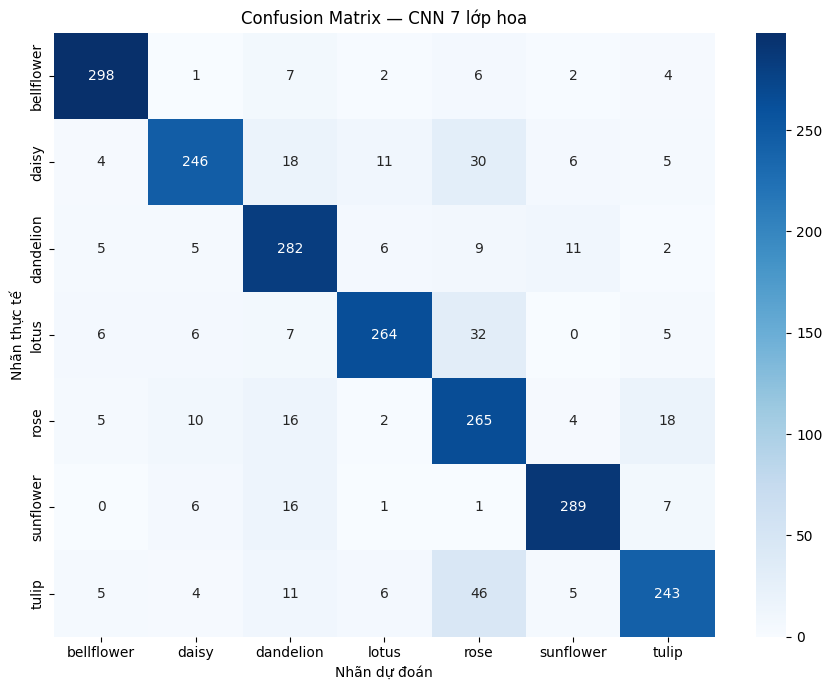

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.title('Confusion Matrix — CNN 7 lớp hoa')
plt.tight_layout()
plt.show()

**Câu hỏi 3:** Nhìn vào Confusion Matrix, lớp nào bị nhận nhầm nhiều nhất? Tại sao theo bạn mô hình lại dễ nhầm 2 lớp đó?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*

### Giải thích Feature Maps

#### Feature Map là gì?

Khi một ảnh đi qua lớp Conv2D, mỗi filter (bộ lọc) tạo ra một **feature map** — một "ảnh mới" thể hiện model đang **chú ý vào đặc trưng gì** của ảnh gốc.

Mỗi pixel trong feature map = mức độ kích hoạt tại vị trí đó:
- **Màu sáng (vàng/xanh lá)** → filter phát hiện thấy đặc trưng mà nó học được tại vị trí đó
- **Màu tối (tím/đen)** → không có đặc trưng tương ứng tại vị trí đó

#### Feature maps thay đổi qua các lớp như thế nào?

| Lớp | Kích thước feature map | Học đặc trưng gì |
|---|---|---|
| **conv2d** (lớp 1) | 62×62 | Cạnh thẳng, góc, chuyển màu đơn giản |
| **conv2d_1** (lớp 2) | 29×29 | Texture (kết cấu cánh hoa, nhụy) |
| **conv2d_2** (lớp 3) | 12×12 | Hình dạng tổng thể, cấu trúc hoa |

Feature map nhỏ dần vì MaxPooling giảm kích thước ÷2 sau mỗi khối. Nhưng mỗi pixel ở lớp sâu hơn "nhìn thấy" vùng rộng hơn của ảnh gốc (receptive field lớn hơn).

#### Nhận xét

- Ở lớp **conv2d_2**, feature maps trở nên trừu tượng hơn — khó nhìn ra hoa, nhưng model đang mã hóa thông tin phân biệt lớp vào đây.
- Một số filter có thể toàn màu tối (không kích hoạt) — filter đó không hữu ích với ảnh cụ thể này nhưng có thể hữu ích với loài hoa khác.
- Đây là lý do tại sao CNN **không cần con người chỉ định đặc trưng** như SIFT/HOG: model tự học feature phù hợp nhất cho bài toán.

## 6. Visualize Feature Maps

Xem model đang "nhìn thấy" gì ở mỗi lớp Conv khi xử lý 1 ảnh hoa.

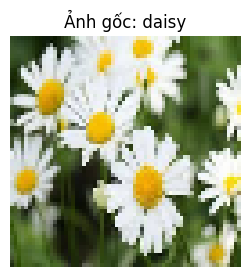

Conv2D layers: ['conv2d_4', 'conv2d_5', 'conv2d_6']


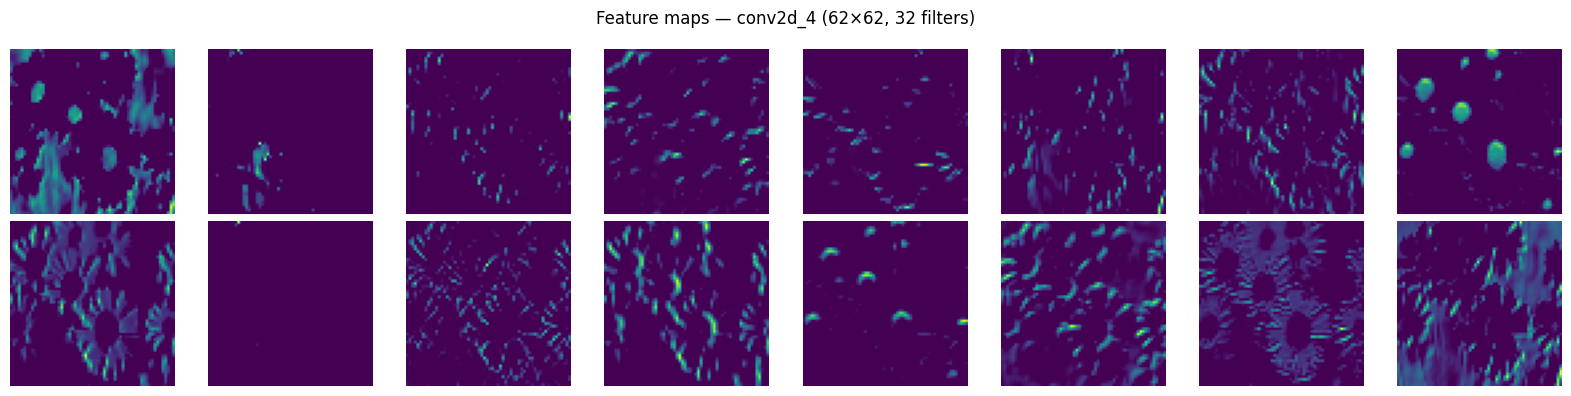

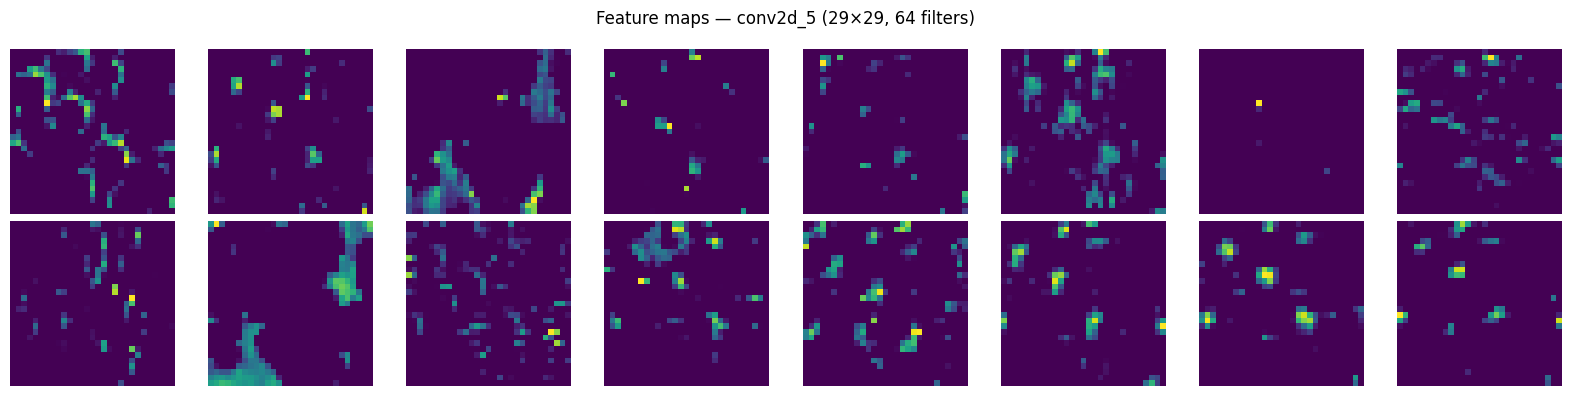

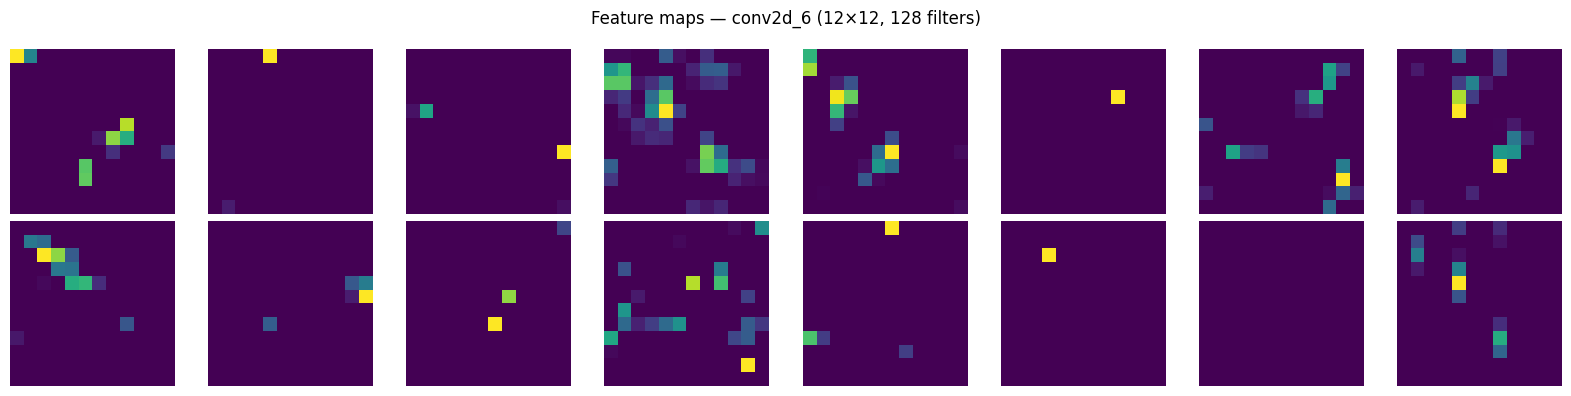

In [16]:
# Lấy 1 ảnh test ngẫu nhiên
sample_idx   = np.random.randint(len(X_test))
sample_image = X_test[sample_idx]
sample_label = CLASSES[y_test[sample_idx]]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title(f'Ảnh gốc: {sample_label}')
plt.axis('off')
plt.show()

# Tự phát hiện tên các lớp Conv2D trong model
layer_names = [l.name for l in best_model.layers if isinstance(l, tf.keras.layers.Conv2D)]
print('Conv2D layers:', layer_names)

def extract_feature_maps(image, model, target_names):
    collected = {}
    x = tf.constant(image[np.newaxis, ...])  # (1, 64, 64, 3)
    for layer in model.layers:
        x = layer(x)
        if layer.name in target_names:
            collected[layer.name] = x.numpy()
    return collected

feature_maps_dict = extract_feature_maps(sample_image, best_model, layer_names)

for layer_name in layer_names:
    fmap = feature_maps_dict[layer_name]
    n_filters = min(16, fmap.shape[-1])
    fig, axes = plt.subplots(2, n_filters // 2, figsize=(16, 4))
    fig.suptitle(f'Feature maps — {layer_name} ({fmap.shape[1]}×{fmap.shape[2]}, {fmap.shape[3]} filters)', fontsize=12)
    for i, ax in enumerate(axes.flat):
        ax.imshow(fmap[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 7. Thử dự đoán 1 ảnh bất kỳ

In [17]:
def predict_image(image_path: str, model):
    img = cv2.imread(image_path)
    if img is None:
        print(f'Không đọc được ảnh: {image_path}')
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (64, 64))
    x = img_resized.astype(np.float32) / 255.0

    probs = model.predict(x[np.newaxis, ...], verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_rgb)
    ax1.set_title(f'Dự đoán: {CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)')
    ax1.axis('off')

    colors = ['#ef4444' if i == pred_idx else '#6366f1' for i in range(len(CLASSES))]
    ax2.barh(CLASSES, probs, color=colors)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Xác suất')
    ax2.set_title('Phân phối xác suất 7 lớp')
    plt.tight_layout()
    plt.show()

# Thay đường dẫn ảnh của bạn vào đây:
# predict_image('path/to/your/flower.jpg', best_model)

## 8. So sánh CNN với các phương pháp truyền thống

| Phương pháp | Extractor | Accuracy (test) | Ghi chú |
|---|---|---|---|
| RandomForest | ORB + BoVW | ~68% | Nhanh, ít dữ liệu |
| XGBoost | ORB + BoVW | ~70.5% | Tốt nhất trong truyền thống |
| SVM (RBF) | ORB + BoVW | ~72% | Hiệu quả với feature thủ công |
| **CNN (3 Conv)** | **Tự học từ pixel** | **84.24%** | Có augmentation nhẹ + Dropout |

**Vì sao CNN tốt hơn nhưng chưa đạt rất cao?**
- Input 64×64 làm mất một phần chi tiết nhỏ ở cánh hoa, nhụy hoa và texture.
- Dataset ~11.200 ảnh vẫn chưa lớn nếu train CNN từ đầu.
- Một số lớp có ngoại hình gần nhau, đặc biệt là `rose`, `tulip`, `daisy`, `lotus`.
- Augmentation hiện tại còn nhẹ, chủ yếu flip/rotate/zoom; chưa xử lý nhiều biến thiên về ánh sáng, crop và background.

**Để cải thiện CNN:**
- Tăng input lên 128×128 hoặc 224×224.
- Thêm data augmentation đa dạng hơn: brightness, contrast, random crop, color jitter.
- Dùng Transfer Learning: MobileNetV2 / EfficientNetB0 pretrained ImageNet → fine-tune.

**Câu hỏi 4:** Nếu dùng Transfer Learning với MobileNetV2, bạn cần thay đổi gì trong bước tiền xử lý ảnh (input_shape, normalize) và tại sao?

$\color{blue}{\textit{Câu trả lời của bạn:}}$ *Điền câu trả lời ở đây*